In [ ]:
import pandas as pd  
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Data Wrangling

In this notebook we will review the data scraped in the `data_scraping.ipynb` notebook and perform wrangling to produce dataset that can be readily used in other notebooks.

## Data Review

In [3]:
# loading data

raw_data = pd.read_csv('../data/uefa_results.csv')
raw_data.head()

,season,competition,round,team_a,country_a,team_b,country_b,score_leg1,score_leg2,score_aggregate,extra_time,penalties
0,1978/79,CL,Qualifying Round,AS Monaco,Fra,Steaua Bucuresti,Rom,3-0,0-2,3-2,no,no
1,1978/79,CL,Round 1,Nottingham Forest,Eng,Liverpool,Eng,2-0,0-0,2-0,no,no
2,1978/79,CL,Round 1,Juventus,Ita,Glasgow Rangers,Sco,1-0,0-2,1-2,no,no
3,1978/79,CL,Round 1,Linfield Belfast,Nir,Lillestrøm SK,Nor,0-0,0-1,0-1,no,no
4,1978/79,CL,Round 1,Real Madrid,Esp,Progrès Niederkorn,Lux,5-0,7-0,12-0,no,no


In [4]:
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 12748 entries, 0 to 12747
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   season           12748 non-null  str  
 1   competition      12748 non-null  str  
 2   round            12748 non-null  str  
 3   team_a           12748 non-null  str  
 4   country_a        12748 non-null  str  
 5   team_b           12748 non-null  str  
 6   country_b        12748 non-null  str  
 7   score_leg1       12748 non-null  str  
 8   score_leg2       11196 non-null  str  
 9   score_aggregate  12748 non-null  str  
 10  extra_time       12748 non-null  str  
 11  penalties        12748 non-null  str  
dtypes: str(12)
memory usage: 1.2 MB


In [5]:
raw_data.nunique()

season               48
competition           4
round                20
team_a             1015
country_a            59
team_b              961
country_b            59
score_leg1           63
score_leg2           68
score_aggregate     135
extra_time            1
penalties             1
dtype: int64

In [6]:
raw_data[raw_data['round'] == 'Final'][:10]

,season,competition,round,team_a,country_a,team_b,country_b,score_leg1,score_leg2,score_aggregate,extra_time,penalties
31,1978/79,CL,Final,Nottingham Forest,Eng,Malmö FF,Swe,1-0,NaN,1-0,no,no
61,1978/79,CW,Final,FC Barcelona,Esp,Fortuna Düsseldorf,Ger,4-3,NaN,4-3,no,no
124,1978/79,EL,Final,Red Star Belgrade,YUG,Borussia Mönchengladbach,Ger,1-1,0-1,1-2,no,no
156,1979/80,CL,Final,Nottingham Forest,Eng,Hamburger SV,Ger,1-0,NaN,1-0,no,no
188,1979/80,CW,Final,Valencia,Esp,Arsenal,Eng,0-0,NaN,0-0,no,no
251,1979/80,EL,Final,Borussia Mönchengladbach,Ger,Eintracht Frankfurt,Ger,3-2,0-1,3-3,no,no
283,1980/81,CL,Final,Liverpool,Eng,Real Madrid,Esp,1-0,NaN,1-0,no,no
316,1980/81,CW,Final,Dinamo Tbilisi,URS,Carl Zeiss Jena,GDR,2-1,NaN,2-1,no,no
379,1980/81,EL,Final,Ipswich Town,Eng,AZ Alkmaar,Ned,3-0,2-4,5-4,no,no
411,1981/82,CL,Final,Aston Villa,Eng,Bayern München,Ger,1-0,NaN,1-0,no,no


In [7]:
raw_data[raw_data['score_leg2'].isna()]

,season,competition,round,team_a,country_a,team_b,country_b,score_leg1,score_leg2,score_aggregate,extra_time,penalties
31,1978/79,CL,Final,Nottingham Forest,Eng,Malmö FF,Swe,1-0,NaN,1-0,no,no
61,1978/79,CW,Final,FC Barcelona,Esp,Fortuna Düsseldorf,Ger,4-3,NaN,4-3,no,no
156,1979/80,CL,Final,Nottingham Forest,Eng,Hamburger SV,Ger,1-0,NaN,1-0,no,no
188,1979/80,CW,Final,Valencia,Esp,Arsenal,Eng,0-0,NaN,0-0,no,no
283,1980/81,CL,Final,Liverpool,Eng,Real Madrid,Esp,1-0,NaN,1-0,no,no
...,...,...,...,...,...,...,...,...,...,...,...,...
12743,2025/26,CO,Round of 16,Fiorentina,Ita,Raków Czestochowa,Pol,2-1,NaN,2-1,no,no
12744,2025/26,CO,Round of 16,Samsunspor,Tur,Rayo Vallecano,Esp,1-3,NaN,1-3,no,no
12745,2025/26,CO,Round of 16,NK Celje,Slo,AEK Athens,Gre,0-4,NaN,0-4,no,no
12746,2025/26,CO,Round of 16,Sigma Olomouc,Cze,FSV Mainz 05,Ger,0-0,NaN,0-0,no,no


In [8]:
raw_data.tail()

,season,competition,round,team_a,country_a,team_b,country_b,score_leg1,score_leg2,score_aggregate,extra_time,penalties
12743,2025/26,CO,Round of 16,Fiorentina,Ita,Raków Czestochowa,Pol,2-1,NaN,2-1,no,no
12744,2025/26,CO,Round of 16,Samsunspor,Tur,Rayo Vallecano,Esp,1-3,NaN,1-3,no,no
12745,2025/26,CO,Round of 16,NK Celje,Slo,AEK Athens,Gre,0-4,NaN,0-4,no,no
12746,2025/26,CO,Round of 16,Sigma Olomouc,Cze,FSV Mainz 05,Ger,0-0,NaN,0-0,no,no
12747,2025/26,CO,Round of 16,NK Rijeka,Cro,RC Strasbourg,Fra,1-2,NaN,1-2,no,no


In [9]:
raw_data['score_leg2'] = raw_data['score_leg2'].fillna('No Match')
raw_data['score_leg2'].head()

0    0-2
1    0-0
2    0-2
3    0-1
4    7-0
Name: score_leg2, dtype: str

In [10]:
raw_data['round'].unique()

<StringArray>
[                'Qualifying Round',                          'Round 1',
                          'Round 2',                   'Quarter Finals',
                      'Semi Finals',                            'Final',
                          'Round 3',                      'Group Stage',
             '1st Qualifying Round',             '2nd Qualifying Round',
             '3rd Qualifying Round',                  '1st Group Stage',
                  '2nd Group Stage',                          'Round 4',
 '4th Qualifying or Play-off Round',        'Qualifying Play-off Round',
                'Preliminary Round',                      'Round of 16',
         'Knockout round play-offs',                     'League Stage']
Length: 20, dtype: str

## Get info functions

Functions to query the raw dataset to sum up useful information

### `get_team_stats`

In [11]:
def get_team_stats(raw_data: pd.DataFrame, team: str) -> dict:
    """
    Compute aggregate statistics for a team.
    
    Each match leg (score_leg1, score_leg2) is treated as a separate game.
    
    Args:
        raw_data: DataFrame with columns ['season', 'team_a', 'team_b', 'score_leg1', 'score_leg2']
        team: Team name to compute stats for (string)
    
    Returns:
        Dictionary with keys:
            - 'seasons': List of seasons the team played (sorted)
            - 'total_seasons': Total number of unique seasons the team played
            - 'total_games': Total number of games (individual legs)
            - 'total_wins': Total number of wins across all games
            - 'total_draws': Total number of draws
            - 'total_losses': Total number of losses
            - 'total_goals_for': Total goals scored by the team
            - 'total_goals_against': Total goals conceded by the team
    """
    
    def parse_score(score_str: str):
        """Parse score string like '3-0' into tuple (goals_for, goals_against)."""
        if pd.isna(score_str) or score_str == 'No Match':
            return None
        try:
            parts = str(score_str).split('-')
            if len(parts) == 2:
                return (int(parts[0]), int(parts[1]))
        except (ValueError, AttributeError):
            pass
        return None
    
    # Filter matches where team is either team_a or team_b
    team_matches = raw_data[
        (raw_data['team_a'] == team) | (raw_data['team_b'] == team)
    ].copy()
    
    # Track seasons
    seasons_set = set(team_matches['season'].unique())
    seasons_list = sorted(list(seasons_set))
    
    # Compute total seasons
    total_seasons = team_matches['season'].nunique()
    
    # Initialize counters
    total_games = 0
    total_wins = 0
    total_draws = 0
    total_losses = 0
    total_goals_for = 0
    total_goals_against = 0
    
    for idx, row in team_matches.iterrows():
        # Process leg 1
        score_leg1 = parse_score(row['score_leg1'])
        if score_leg1 is not None:
            total_games += 1
            if row['team_a'] == team:
                goals_for, goals_against = score_leg1
            else:  # team is team_b
                goals_against, goals_for = score_leg1
            
            total_goals_for += goals_for
            total_goals_against += goals_against
            
            if goals_for > goals_against:
                total_wins += 1
            elif goals_for == goals_against:
                total_draws += 1
            else:
                total_losses += 1
        
        # Process leg 2
        score_leg2 = parse_score(row['score_leg2'])
        if score_leg2 is not None:
            total_games += 1
            if row['team_a'] == team:
                goals_for, goals_against = score_leg2
            else:  # team is team_b
                goals_against, goals_for = score_leg2
            
            total_goals_for += goals_for
            total_goals_against += goals_against
            
            if goals_for > goals_against:
                total_wins += 1
            elif goals_for == goals_against:
                total_draws += 1
            else:
                total_losses += 1
    
    return {
        'seasons': seasons_list,
        'total_seasons': total_seasons,
        'total_games': total_games,
        'total_wins': total_wins,
        'total_draws': total_draws,
        'total_losses': total_losses,
        'total_goals_for': total_goals_for,
        'total_goals_against': total_goals_against
    }

In [12]:
# Test the function with a few examples
# example_teams = ['Real Madrid', 'Juventus', 'Napoli']
# for team_name in example_teams:
#     stats = get_team_stats(raw_data, team_name)
#     print(f"\n{team_name}:")
#     print(f"  Seasons played: {stats['seasons']}")
#     print(f"  Total seasons: {stats['total_seasons']}")
#     print(f"  Total games: {stats['total_games']}")
#     print(f"  Total wins: {stats['total_wins']}")
#     print(f"  Total draws: {stats['total_draws']}")
#     print(f"  Total losses: {stats['total_losses']}")
#     print(f"  Total goals for: {stats['total_goals_for']}")
#     print(f"  Total goals against: {stats['total_goals_against']}")

### `get_countries_seasons_details`

In [13]:
def get_countries_seasons_details(raw_data: pd.DataFrame, season: list, country: list) -> pd.DataFrame:
    """Get all matches involving specific country/countries in a specific season/seasons."""
    return raw_data[
        (raw_data['season'].isin(season)) & 
        ((raw_data['country_a'].isin(country)) | (raw_data['country_b'].isin(country)))
    ]

### `get_team_matches`

In [14]:
def get_team_matches(raw_data: pd.DataFrame, season: list, team: str) -> pd.DataFrame:
    """Get all matches involving a specific team in a specific season/seasons."""
    if season == []:
        return raw_data[(raw_data['team_a'] == team) | (raw_data['team_b'] == team)]
    return raw_data[
        (raw_data['season'].isin(season)) & 
        ((raw_data['team_a'] == team) | (raw_data['team_b'] == team))
    ]

In [15]:
get_team_matches(raw_data, season = ['2007/08', '2009/10'], team='Slaven Koprivnica')

,season,competition,round,team_a,country_a,team_b,country_b,score_leg1,score_leg2,score_aggregate,extra_time,penalties
5436,2007/08,EL,1st Qualifying Round,Slaven Koprivnica,Cro,Teuta Durrës,Alb,6-2,2-2,8-4,no,no
5469,2007/08,EL,2nd Qualifying Round,Slaven Koprivnica,Cro,Galatasaray,Tur,1-2,1-2,2-4,no,no
6070,2009/10,EL,1st Qualifying Round,Slaven Koprivnica,Cro,Birkirkara,Mlt,1-0,0-0,1-0,no,no
6106,2009/10,EL,2nd Qualifying Round,Milano Kumanovo,Mac,Slaven Koprivnica,Cro,0-4,2-8,2-12,no,no
6140,2009/10,EL,3rd Qualifying Round,Tromsø IL,Nor,Slaven Koprivnica,Cro,2-1,2-0,4-1,no,no


### `country_season_stats`

In [16]:
def country_season_stats(df: pd.DataFrame) -> pd.DataFrame:
    """Compute per-country season stats for every team from that country.

    Each match leg (`score_leg1`, `score_leg2`) is treated as a separate game.
    Each team contributes stats for its country (so foreign opponents are included).

    Returns a DataFrame with columns:
      - country
      - season
      - num_teams: Number of unique teams from that country that played in that season
      - wins
      - draws
      - losses
      - goals_for
      - goals_against

    For countries that did not participate in a season, all numerical columns are filled with 0.

    Args:
        df: Raw data frame with columns ['season', 'team_a', 'team_b', 'country_a', 'country_b', 'score_leg1', 'score_leg2'].
    """

    def _parse_score(score: str):
        if pd.isna(score):
            return None, None
        parts = str(score).split("-")
        if len(parts) != 2:
            return None, None
        try:
            return int(parts[0].strip()), int(parts[1].strip())
        except ValueError:
            return None, None

    def _expand_leg(df_leg: pd.DataFrame, score_col: str, team_col: str, opp_col: str, country_col: str, reverse_score: bool = False):
        tmp = df_leg[["season", team_col, opp_col, country_col, score_col]].copy()
        tmp = tmp.rename(columns={
            team_col: "team",
            opp_col: "opp",
            country_col: "country",
            score_col: "score",
        })

        parsed = tmp["score"].apply(_parse_score).tolist()
        if reverse_score:
            # For away team: goals_for is the second number, goals_against is the first
            tmp[["goals_against", "goals_for"]] = pd.DataFrame(parsed, index=tmp.index)
        else:
            # For home team: goals_for is the first number, goals_against is the second
            tmp[["goals_for", "goals_against"]] = pd.DataFrame(parsed, index=tmp.index)

        # Determine result from the perspective of `team`
        tmp["result"] = np.where(
            tmp["goals_for"] > tmp["goals_against"],
            "W",
            np.where(tmp["goals_for"] < tmp["goals_against"], "L", "D"),
        )

        return tmp.drop(columns=["score", "opp"])

    # Expand all 4 combinations: both teams in both legs
    # Leg 1: score_leg1 = team_a_goals - team_b_goals
    leg1_team_a = _expand_leg(df, "score_leg1", "team_a", "team_b", "country_a", reverse_score=False)
    leg1_team_b = _expand_leg(df, "score_leg1", "team_b", "team_a", "country_b", reverse_score=True)
    
    # Leg 2: score_leg2 = team_a_goals - team_b_goals (same format as leg1)
    leg2_team_a = _expand_leg(df, "score_leg2", "team_a", "team_b", "country_a", reverse_score=False)
    leg2_team_b = _expand_leg(df, "score_leg2", "team_b", "team_a", "country_b", reverse_score=True)

    matches = pd.concat([leg1_team_a, leg1_team_b, leg2_team_a, leg2_team_b], ignore_index=True, sort=False)

    matches = matches.dropna(subset=["goals_for", "goals_against"])

    stats = (
        matches.groupby(["country", "season"])
        .agg(
            num_teams=("team", "nunique"),
            wins=("result", lambda s: (s == "W").sum()),
            draws=("result", lambda s: (s == "D").sum()),
            losses=("result", lambda s: (s == "L").sum()),
            goals_for=("goals_for", "sum"),
            goals_against=("goals_against", "sum"),
        )
        .reset_index()
    )

    # Create a complete index with all country-season combinations
    all_countries = stats["country"].unique()
    all_seasons = stats["season"].unique()
    complete_index = pd.MultiIndex.from_product(
        [sorted(all_countries), sorted(all_seasons)],
        names=["country", "season"]
    )
    
    # Reindex to include all combinations, filling missing ones with 0
    stats = stats.set_index(["country", "season"]).reindex(complete_index, fill_value=0).reset_index()

    return stats

# Example usage:
country_stats = country_season_stats(raw_data)
country_stats.head()


,country,season,num_teams,wins,draws,losses,goals_for,goals_against
0,Alb,1978/79,1,1,0,1,3.0,4.0
1,Alb,1979/80,1,1,0,1,2.0,4.0
2,Alb,1980/81,2,0,1,3,0.0,4.0
3,Alb,1981/82,2,2,0,2,3.0,7.0
4,Alb,1982/83,2,1,1,2,2.0,3.0


### Highest round for each country in season

Implementing a function to retrieve the highest round reached, in which competition, by country in each season.

- input: raw_data dataframe
- output: dataframe

In [17]:
raw_data.columns

Index(['season', 'competition', 'round', 'team_a', 'country_a', 'team_b',
       'country_b', 'score_leg1', 'score_leg2', 'score_aggregate',
       'extra_time', 'penalties'],
      dtype='str')

In [18]:
def get_country_season_highest_round(raw_data: pd.DataFrame) -> pd.DataFrame:
    """
    For each season and each country assign the highest stage reached by any team
    from that country and list competitions where that highest stage was reached.
    """
    stage_group = {
        "qualifying round",
        "4th qualifying or play-off round",
        "qualifying play-off round",
        "preliminary round",
        "round 1",
        "round 2",
        "round 3",
        "round 4",
        "1st qualifying round",
        "2nd qualifying round",
        "3rd qualifying round",
        "group stage",
        "1st group stage",
        "2nd group stage",
        "knockout round play-offs",
        "league stage",
    }

    def normalize_round(rnd):
        if pd.isna(rnd):
            return None
        r = str(rnd).strip()
        if not r:
            return None
        key = r.lower()
        if key in stage_group:
            return "stage"
        if "round of 16" in key:
            return "Round of 16"
        if "quarter" in key:
            return "Quarter Finals"
        if "semi" in key:
            return "Semi Finals"
        if key == "final" or "final" in key:
            # final may appear as "Final" or "Finals"
            return "Final"
        # fallback for unknown or other early/qualifiers
        return "stage"

    rank_map = {"stage": 1, "Round of 16": 2, "Quarter Finals": 3, "Semi Finals": 4, "Final": 5}
    rank_to_round = {v: k for k, v in rank_map.items()}

    df_a = raw_data[["season", "country_a", "competition", "round"]].rename(
        columns={"country_a": "country"}
    )
    df_b = raw_data[["season", "country_b", "competition", "round"]].rename(
        columns={"country_b": "country"}
    )
    stacked = pd.concat([df_a, df_b], ignore_index=True, sort=False)
    stacked["stage"] = stacked["round"].apply(normalize_round)
    stacked = stacked.dropna(subset=["country", "stage"])

    stacked["stage_rank"] = stacked["stage"].map(rank_map).fillna(1).astype(int)

    stats = stacked.groupby(["season", "country"]).agg(max_rank=("stage_rank", "max")).reset_index()

    best_comps = (
        stacked.loc[
            stacked.groupby(["season", "country"])["stage_rank"].transform("max")
            == stacked["stage_rank"]
        ]
        .groupby(["season", "country"])["competition"]
        .agg(lambda x: sorted(list(set(x))))
        .reset_index()
    )

    result = stats.merge(best_comps, on=["season", "country"], how="left")
    result["highest round"] = result["max_rank"].map(rank_to_round)
    result = result[["season", "country", "highest round", "competition"]]

    all_seasons = sorted(raw_data["season"].dropna().unique())
    all_countries = sorted(
        pd.unique(
            pd.concat(
                [raw_data["country_a"].dropna(), raw_data["country_b"].dropna()], ignore_index=True
            )
        )
    )

    full_index = pd.MultiIndex.from_product([all_seasons, all_countries], names=["season", "country"])
    result_full = pd.DataFrame(index=full_index).reset_index().merge(result, on=["season", "country"], how="left")

    result_full["highest round"] = result_full["highest round"].fillna("not partecipate")
    
    def _ensure_flat_list(x):
        """Ensure competition column contains flat lists, not nested."""
        if x is None or (isinstance(x, float) and pd.isna(x)):
            return []
        if isinstance(x, list):
            # If it's a list of lists, flatten it
            if x and isinstance(x[0], list):
                return [item for sublist in x for item in sublist]
            return x
        if isinstance(x, np.ndarray):
            return list(x)
        return []
    
    result_full["competition"] = result_full["competition"].apply(_ensure_flat_list)

    return result_full

In [19]:
raw_data.head()

,season,competition,round,team_a,country_a,team_b,country_b,score_leg1,score_leg2,score_aggregate,extra_time,penalties
0,1978/79,CL,Qualifying Round,AS Monaco,Fra,Steaua Bucuresti,Rom,3-0,0-2,3-2,no,no
1,1978/79,CL,Round 1,Nottingham Forest,Eng,Liverpool,Eng,2-0,0-0,2-0,no,no
2,1978/79,CL,Round 1,Juventus,Ita,Glasgow Rangers,Sco,1-0,0-2,1-2,no,no
3,1978/79,CL,Round 1,Linfield Belfast,Nir,Lillestrøm SK,Nor,0-0,0-1,0-1,no,no
4,1978/79,CL,Round 1,Real Madrid,Esp,Progrès Niederkorn,Lux,5-0,7-0,12-0,no,no


In [20]:
# Example usage
country_season_highest = get_country_season_highest_round(raw_data)
country_season_highest.head(10)

,season,country,highest round,competition
0,1978/79,Alb,stage,[CL]
1,1978/79,And,not partecipate,[]
2,1978/79,Arm,not partecipate,[]
3,1978/79,Aut,Semi Finals,[CL]
4,1978/79,Azb,not partecipate,[]
5,1978/79,Bel,Semi Finals,[CW]
6,1978/79,Bls,not partecipate,[]
7,1978/79,Bos,not partecipate,[]
8,1978/79,Bul,stage,"[CL, CW, EL]"
9,1978/79,Cro,not partecipate,[]


In [21]:
# Debug: Check what's happening in the function
import pandas as pd

raw_data = pd.read_csv('../data/uefa_results.csv')

# Quick test of the best_comps/result merge
stage_group = {
    "qualifying round", "4th qualifying or play-off round", "qualifying play-off round",
    "preliminary round", "round 1", "round 2", "round 3", "round 4",
    "1st qualifying round", "2nd qualifying round", "3rd qualifying round",
    "group stage", "1st group stage", "2nd group stage", "knockout round play-offs", "league stage",
}

def normalize_round(rnd):
    if pd.isna(rnd):
        return None
    r = str(rnd).strip()
    if not r:
        return None
    key = r.lower()
    if key in stage_group:
        return "stage"
    if "round of 16" in key:
        return "Round of 16"
    if "quarter" in key:
        return "Quarter Finals"
    if "semi" in key:
        return "Semi Finals"
    if key == "final" or "final" in key:
        return "Final"
    return "stage"

rank_map = {"stage": 1, "Round of 16": 2, "Quarter Finals": 3, "Semi Finals": 4, "Final": 5}
rank_to_round = {v: k for k, v in rank_map.items()}

df_a = raw_data[["season", "country_a", "competition", "round"]].rename(columns={"country_a": "country"})
df_b = raw_data[["season", "country_b", "competition", "round"]].rename(columns={"country_b": "country"})
stacked = pd.concat([df_a, df_b], ignore_index=True, sort=False)
stacked["stage"] = stacked["round"].apply(normalize_round)
stacked = stacked.dropna(subset=["country", "stage"])
stacked["stage_rank"] = stacked["stage"].map(rank_map).fillna(1).astype(int)

stats = stacked.groupby(["season", "country"]).agg(max_rank=("stage_rank", "max")).reset_index()
print("Stats columns:", stats.columns.tolist())
print("Stats sample:")
print(stats.head())

best_comps = (
    stacked.loc[
        stacked.groupby(["season", "country"])["stage_rank"].transform("max") == stacked["stage_rank"]
    ]
    .groupby(["season", "country"])["competition"]
    .agg(lambda x: sorted(list(set(x))))
    .reset_index()
)
print("\nBest_comps columns:", best_comps.columns.tolist())
print("Best_comps sample:")
print(best_comps.head())

result = stats.merge(best_comps, on=["season", "country"], how="left")
print("\nResult columns after merge:", result.columns.tolist())
print("Result sample:")
print(result.head())

Stats columns: ['season', 'country', 'max_rank']
Stats sample:
    season country  max_rank
0  1978/79     Alb         1
1  1978/79     Aut         4
2  1978/79     Bel         4
3  1978/79     Bul         1
4  1978/79     Cyp         1

Best_comps columns: ['season', 'country', 'competition']
Best_comps sample:
    season country   competition
0  1978/79     Alb          [CL]
1  1978/79     Aut          [CL]
2  1978/79     Bel          [CW]
3  1978/79     Bul  [CL, CW, EL]
4  1978/79     Cyp  [CL, CW, EL]

Result columns after merge: ['season', 'country', 'max_rank', 'competition']
Result sample:
    season country  max_rank   competition
0  1978/79     Alb         1          [CL]
1  1978/79     Aut         4          [CL]
2  1978/79     Bel         4          [CW]
3  1978/79     Bul         1  [CL, CW, EL]
4  1978/79     Cyp         1  [CL, CW, EL]


In [22]:
country_season_highest[country_season_highest['country'] == 'Ita'].head(10)

,season,country,highest round,competition
28,1978/79,Ita,Quarter Finals,[CW]
87,1979/80,Ita,Semi Finals,[CW]
146,1980/81,Ita,Semi Finals,[CL]
205,1981/82,Ita,stage,"[CL, CW, EL]"
264,1982/83,Ita,Final,[CL]
323,1983/84,Ita,Final,"[CL, CW]"
382,1984/85,Ita,Final,[CL]
441,1985/86,Ita,Semi Finals,[EL]
500,1986/87,Ita,Quarter Finals,[EL]
559,1987/88,Ita,Semi Finals,[CW]


In [23]:
def get_country_season_competition_highest_round(raw_data: pd.DataFrame) -> pd.DataFrame:
    """
    For each season/country/competition, report highest round reached by a team from that country.
    Missing combos get 'not partecipate' for both competition and highest_round.
    """
    stage_group = {
        "qualifying round", "4th qualifying or play-off round", "qualifying play-off round",
        "preliminary round", "round 1", "round 2", "round 3", "round 4",
        "1st qualifying round", "2nd qualifying round", "3rd qualifying round",
        "group stage", "1st group stage", "2nd group stage", "knockout round play-offs",
        "league stage",
    }

    def normalize_round(rnd):
        if pd.isna(rnd):
            return None
        r = str(rnd).strip()
        if not r:
            return None
        key = r.lower()
        if key in stage_group:
            return "stage"
        if "round of 16" in key:
            return "Round of 16"
        if "quarter" in key:
            return "Quarter Finals"
        if "semi" in key:
            return "Semi Finals"
        if key == "final" or "final" in key:
            return "Final"
        return "stage"

    rank_map = {"stage": 1, "Round of 16": 2, "Quarter Finals": 3, "Semi Finals": 4, "Final": 5}
    rank_to_round = {v: k for k, v in rank_map.items()}

    df_a = raw_data[["season", "country_a", "competition", "round"]].rename(columns={"country_a": "country"})
    df_b = raw_data[["season", "country_b", "competition", "round"]].rename(columns={"country_b": "country"})
    stacked = pd.concat([df_a, df_b], ignore_index=True, sort=False)

    stacked["stage"] = stacked["round"].apply(normalize_round)
    stacked = stacked.dropna(subset=["season", "country", "competition", "stage"])
    stacked["stage_rank"] = stacked["stage"].map(rank_map).fillna(1).astype(int)

    stats = (
        stacked.groupby(["season", "country", "competition"])
        .agg(max_rank=("stage_rank", "max"))
        .reset_index()
    )
    stats["highest_round"] = stats["max_rank"].map(rank_to_round).fillna("stage")

    all_seasons = sorted(raw_data["season"].dropna().unique())
    all_countries = sorted(
        pd.unique(
            pd.concat([raw_data["country_a"].dropna(), raw_data["country_b"].dropna()], ignore_index=True)
        )
    )
    all_competitions = sorted(raw_data["competition"].dropna().unique())

    full_index = pd.MultiIndex.from_product(
        [all_seasons, all_countries, all_competitions],
        names=["season", "country", "competition"],
    )
    result_full = pd.DataFrame(index=full_index).reset_index()

    result_full = result_full.merge(
        stats[["season", "country", "competition", "highest_round"]],
        on=["season", "country", "competition"],
        how="left",
    )

    missing = result_full["highest_round"].isna()
    result_full.loc[missing, "highest_round"] = "not partecipate"

    # Ensure dtypes are string
    result_full["season"] = result_full["season"].astype(str)
    result_full["country"] = result_full["country"].astype(str)
    result_full["competition"] = result_full["competition"].astype(str)
    result_full["highest_round"] = result_full["highest_round"].astype(str)

    return result_full


country_season_competition_highest = get_country_season_competition_highest_round(raw_data)
country_season_competition_highest.head(10)

,season,country,competition,highest_round
0,1978/79,Alb,CL,stage
1,1978/79,Alb,CO,not partecipate
2,1978/79,Alb,CW,not partecipate
3,1978/79,Alb,EL,not partecipate
4,1978/79,And,CL,not partecipate
5,1978/79,And,CO,not partecipate
6,1978/79,And,CW,not partecipate
7,1978/79,And,EL,not partecipate
8,1978/79,Arm,CL,not partecipate
9,1978/79,Arm,CO,not partecipate


In [24]:
country_season_competition_highest[country_season_competition_highest['country'] == 'Eng'][40:50] 

,season,country,competition,highest_round
2412,1988/89,Eng,CL,not partecipate
2413,1988/89,Eng,CO,not partecipate
2414,1988/89,Eng,CW,not partecipate
2415,1988/89,Eng,EL,not partecipate
2648,1989/90,Eng,CL,not partecipate
2649,1989/90,Eng,CO,not partecipate
2650,1989/90,Eng,CW,not partecipate
2651,1989/90,Eng,EL,not partecipate
2884,1990/91,Eng,CL,not partecipate
2885,1990/91,Eng,CO,not partecipate


In [25]:
get_country_season_highest_round(raw_data).head(10)

,season,country,highest round,competition
0,1978/79,Alb,stage,[CL]
1,1978/79,And,not partecipate,[]
2,1978/79,Arm,not partecipate,[]
3,1978/79,Aut,Semi Finals,[CL]
4,1978/79,Azb,not partecipate,[]
5,1978/79,Bel,Semi Finals,[CW]
6,1978/79,Bls,not partecipate,[]
7,1978/79,Bos,not partecipate,[]
8,1978/79,Bul,stage,"[CL, CW, EL]"
9,1978/79,Cro,not partecipate,[]


In [26]:
def plot_country_season_highest_round(country_season_highest: pd.DataFrame, countries: list, figsize=(14, 6)):
    """
    Plot highest round reached by country for each season.
    
    - country_season_highest: output of get_country_season_highest_round
    - countries: list of country codes
    """
    rank_map = {
        "not partecipate": 0,
        "stage": 1,
        "Round of 16": 2,
        "Quarter Finals": 3,
        "Semi Finals": 4,
        "Final": 5,
    }
    rank_to_label = {v: k for k, v in rank_map.items()}
    
    df = country_season_highest.copy()
    df["rank"] = df["highest round"].map(rank_map).fillna(0).astype(int)
    
    seasons = sorted(df["season"].unique(), key=lambda s: (int(s.split("/")[0]), int(s.split("/")[1])))
    df["season"] = pd.Categorical(df["season"], categories=seasons, ordered=True)
    
    sns.set_style("whitegrid")
    fig, ax = plt.subplots(figsize=figsize)
    
    palette = sns.color_palette("tab10", len(countries))
    markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h', '+', 'x']
    not_played_legend_added = False
    
    for i, c in enumerate(countries):
        cdf = df[df["country"] == c].sort_values("season")
        if cdf.empty:
            continue
        
        played = cdf[cdf["rank"] > 0]
        not_played = cdf[cdf["rank"] == 0]
        
        marker = markers[i % len(markers)]
        
        ax.plot(
            played["season"],
            played["rank"],
            marker=marker,
            linestyle="-",
            label=c,
            color=palette[i % len(palette)],
            alpha=0.8,
            linewidth=1.7,
        )
        if not_played.shape[0] > 0:
            ax.scatter(
                not_played["season"],
                not_played["rank"],
                marker="x",
                s=90,
                color=palette[i % len(palette)],
                linewidths=2,
                label="not partecipate" if not not_played_legend_added else "",
                alpha=0.9,
            )
            not_played_legend_added = True
    
    ax.set_xticks(seasons[::max(1, len(seasons)//20)])
    ax.set_xticklabels(seasons[::max(1, len(seasons)//20)], rotation=75, ha="right")
    
    ax.set_yticks(list(rank_to_label.keys()))
    ax.set_yticklabels([rank_to_label[x] for x in sorted(rank_to_label.keys())])
    
    ax.set_title("Highest Round Reached by Country per Season")
    ax.set_xlabel("Season")
    ax.set_ylabel("Highest Stage (ranked)")
    ax.legend(title="Country / status", fontsize=9, loc="center left", bbox_to_anchor=(1, 0.5))
    ax.grid(True, axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()
    
    return fig, ax



(<Figure size 1400x600 with 1 Axes>,
 <Axes: title={'center': 'Highest Round Reached by Country per Season'}, xlabel='Season', ylabel='Highest Stage (ranked)'>)

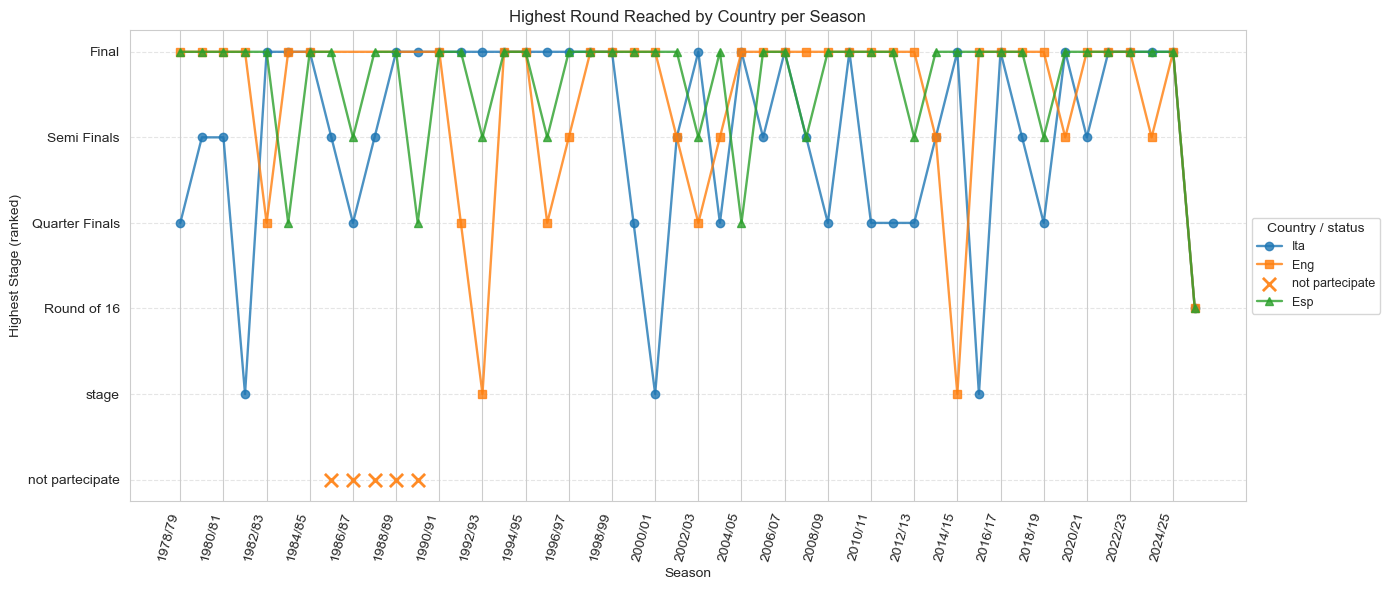

In [27]:
# Example usage:
plot_country_season_highest_round(country_season_highest, ["Ita", "Eng", "Esp"])

### Checking Data Consistency

Running the following cells to check data consistency

In [28]:
season = ['1978/79', '1993/94']
country = 'Ita'

raw_data[(raw_data['season'].isin(season)) & ((raw_data['country_a'] == 'Ita') | (raw_data['country_b'] == 'Ita'))]

,season,competition,round,team_a,country_a,team_b,country_b,score_leg1,score_leg2,score_aggregate,extra_time,penalties
2,1978/79,CL,Round 1,Juventus,Ita,Glasgow Rangers,Sco,1-0,0-2,1-2,no,no
32,1978/79,CW,Round 1,Floriana,Mlt,Internazionale,Ita,1-3,0-5,1-8,no,no
51,1978/79,CW,Round 2,Internazionale,Ita,Bodø/Glimt,Nor,5-0,2-1,7-1,no,no
55,1978/79,CW,Quarter Finals,Internazionale,Ita,SK Beveren,Bel,0-0,0-1,0-1,no,no
62,1978/79,EL,Round 1,Dukla Praha,TCH,Vicenza,Ita,1-0,1-1,2-1,no,no
63,1978/79,EL,Round 1,AC Milan,Ita,Lokomotiva Kosice,TCH,1-0,0-1,1-1,no,no
71,1978/79,EL,Round 1,Sporting Gijón,Esp,Torino,Ita,3-0,0-1,3-1,no,no
90,1978/79,EL,Round 1,Dinamo Tbilisi,URS,Napoli,Ita,2-0,1-1,3-1,no,no
109,1978/79,EL,Round 2,Levski-Spartak Sofia,Bul,AC Milan,Ita,1-1,0-3,1-4,no,no
117,1978/79,EL,Round 3,AC Milan,Ita,Manchester City,Eng,2-2,0-3,2-5,no,no


## Additional metrics

In [29]:
country_stats.head(2)

,country,season,num_teams,wins,draws,losses,goals_for,goals_against
0,Alb,1978/79,1,1,0,1,3.0,4.0
1,Alb,1979/80,1,1,0,1,2.0,4.0


The `country_stats` dataframe contains the basic information, we now derive other metrics that might be useful in the following analysis.

This is the list of the metrics:
- `total_matches`: total number of matches played in that season
- `win_rate`: percentage of wins
- `loss_rate`: percentage of losses
- `draw_rate`: percentage of draws
- `ppg_3`: points per game considering 3 points for wins
- `ppg_2`: points per game considering 2 points for wins
- `goal_diff`: goal difference
- `gf_pg`: goal for per game
- `ga_pg`: goal against per game
- `gdpg`: goal difference per game

In [30]:
def add_derived_metrics(df: pd.DataFrame) -> pd.DataFrame:
    """
    Expand country_stats with derived performance metrics.
    
    Parameters
    ----------
    df : pd.DataFrame
        Must contain: wins, draws, losses, goals_for, goals_against

    Returns
    -------
    pd.DataFrame
        Original dataframe with derived metric columns appended.
    """
    df = df.copy()

    # --- Denominator ---
    df["total_matches"] = df["wins"] + df["draws"] + df["losses"]

    # --- Rates ---
    df["win_rate"]  = df["wins"]   / df["total_matches"]
    df["draw_rate"] = df["draws"]  / df["total_matches"]
    df["loss_rate"] = df["losses"] / df["total_matches"]

    # --- Points per game ---
    df["ppg_3"] = (df["wins"] * 3 + df["draws"])     / df["total_matches"]
    df["ppg_2"] = (df["wins"] * 2 + df["draws"])     / df["total_matches"]

    # --- Goal metrics ---
    df["goal_diff"] = df["goals_for"] - df["goals_against"]
    df["gf_pg"]     = df["goals_for"]    / df["total_matches"]
    df["ga_pg"]     = df["goals_against"] / df["total_matches"]
    df["gdpg"]      = df["goal_diff"]    / df["total_matches"]

    return df

In [31]:
country_stats_complete = add_derived_metrics(country_stats)
country_stats_complete.head()

,country,season,num_teams,wins,draws,losses,goals_for,goals_against,total_matches,win_rate,draw_rate,loss_rate,ppg_3,ppg_2,goal_diff,gf_pg,ga_pg,gdpg
0,Alb,1978/79,1,1,0,1,3.0,4.0,2,0.50,0.00,0.50,1.50,1.00,-1.0,1.50,2.00,-0.50
1,Alb,1979/80,1,1,0,1,2.0,4.0,2,0.50,0.00,0.50,1.50,1.00,-2.0,1.00,2.00,-1.00
2,Alb,1980/81,2,0,1,3,0.0,4.0,4,0.00,0.25,0.75,0.25,0.25,-4.0,0.00,1.00,-1.00
3,Alb,1981/82,2,2,0,2,3.0,7.0,4,0.50,0.00,0.50,1.50,1.00,-4.0,0.75,1.75,-1.00
4,Alb,1982/83,2,1,1,2,2.0,3.0,4,0.25,0.25,0.50,1.00,0.75,-1.0,0.50,0.75,-0.25


In [32]:
country_stats_complete[country_stats_complete['country'] == 'Eng']

,country,season,num_teams,wins,draws,losses,goals_for,goals_against,total_matches,win_rate,draw_rate,loss_rate,ppg_3,ppg_2,goal_diff,gf_pg,ga_pg,gdpg
624,Eng,1978/79,7,23,12,8,75.0,35.0,43,0.534884,0.279070,0.186047,1.883721,1.348837,40.0,1.744186,0.813953,0.930233
625,Eng,1979/80,7,15,8,9,47.0,26.0,32,0.468750,0.250000,0.281250,1.656250,1.187500,21.0,1.468750,0.812500,0.656250
626,Eng,1980/81,6,18,5,10,67.0,32.0,33,0.545455,0.151515,0.303030,1.787879,1.242424,35.0,2.030303,0.969697,1.060606
627,Eng,1981/82,7,18,8,9,53.0,29.0,35,0.514286,0.228571,0.257143,1.771429,1.257143,24.0,1.514286,0.828571,0.685714
628,Eng,1982/83,7,10,5,9,43.0,35.0,24,0.416667,0.208333,0.375000,1.458333,1.041667,8.0,1.791667,1.458333,0.333333
629,Eng,1983/84,6,27,12,10,88.0,44.0,49,0.551020,0.244898,0.204082,1.897959,1.346939,44.0,1.795918,0.897959,0.897959
630,Eng,1984/85,7,24,10,8,75.0,27.0,42,0.571429,0.238095,0.190476,1.952381,1.380952,48.0,1.785714,0.642857,1.142857
631,Eng,1985/86,0,0,0,0,0.0,0.0,0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN
632,Eng,1986/87,0,0,0,0,0.0,0.0,0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN
633,Eng,1987/88,0,0,0,0,0.0,0.0,0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN


In [33]:
# implement a function to plot the desired metrics for the selected countries

def plot_country_metrics(df: pd.DataFrame, countries: list,  metric: str, figsize = (12, 6)):
    '''Plot the specified metric for the given countries and seasons.
    
    Each country has a unique line marker. Where data is NaN (indicating seasons 
    where no teams from that country participated), a special 'X' marker is displayed
    to indicate missing data.
    '''
    
    # Define different markers for each country
    markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']
    
    # Metric descriptions for meaningful titles
    metric_descriptions = {
        'total_matches': 'Total Matches per Season',
        'win_rate': 'Win Rate (%)',
        'loss_rate': 'Loss Rate (%)',
        'draw_rate': 'Draw Rate (%)',
        'ppg_3': 'Points Per Game (3pts for Win)',
        'ppg_2': 'Points Per Game (2pts for Win)',
        'goal_diff': 'Goal Difference',
        'gf_pg': 'Goals For per Game',
        'ga_pg': 'Goals Against per Game',
        'gdpg': 'Goal Difference per Game'
    }
    
    sns.set_style("whitegrid")
    fig, ax = plt.subplots(figsize=figsize)
    
    dataset = df[df['country'].isin(countries)].copy()
    
    # Get color palette for consistent coloring
    palette = sns.color_palette("husl", len(countries))
    color_map = {country: palette[i] for i, country in enumerate(countries)}
    
    # Track if we've added the NaN label (add only once to legend)
    nan_label_added = False
    
    for i, country in enumerate(countries):
        country_data = dataset[dataset['country'] == country].sort_values('season')
        marker = markers[i % len(markers)]
        color = color_map[country]
        
        # Plot line with markers for non-NaN values (gaps appear at NaN)
        ax.plot(country_data['season'], country_data[metric], 
                marker=marker, label=country, linewidth=1.5, 
                markersize=4, color=color)
        
        # Add special 'X' markers for NaN values to indicate "no data"
        nan_mask = country_data[metric].isna()
        if nan_mask.any():
            nan_seasons = country_data.loc[nan_mask, 'season'].values
            # Position NaN markers slightly below the minimum y value
            y_min = ax.get_ylim()[0]
            nan_y = [y_min] * len(nan_seasons)
            
            ax.scatter(nan_seasons, nan_y, marker='x', s=200, 
                      color=color, linewidths=1.5, alpha=0.6, zorder=5,
                      label='No matches' if not nan_label_added else '')
            
            if not nan_label_added:
                nan_label_added = True
    
    # Adjust y-axis to accommodate NaN markers at the bottom
    y_min, y_max = ax.get_ylim()
    ax.set_ylim(y_min - (y_max - y_min) * 0.12, y_max)
    
    # Use descriptive title if metric is in the descriptions dictionary
    metric_title = metric_descriptions.get(metric, metric)
    
    plt.xticks(rotation=70)
    plt.title(f"{metric_title} by Country over Seasons")
    plt.xlabel("Season")
    plt.ylabel(metric_title)
    plt.legend(title='Country', fontsize=9)
    plt.tight_layout()
    plt.show()

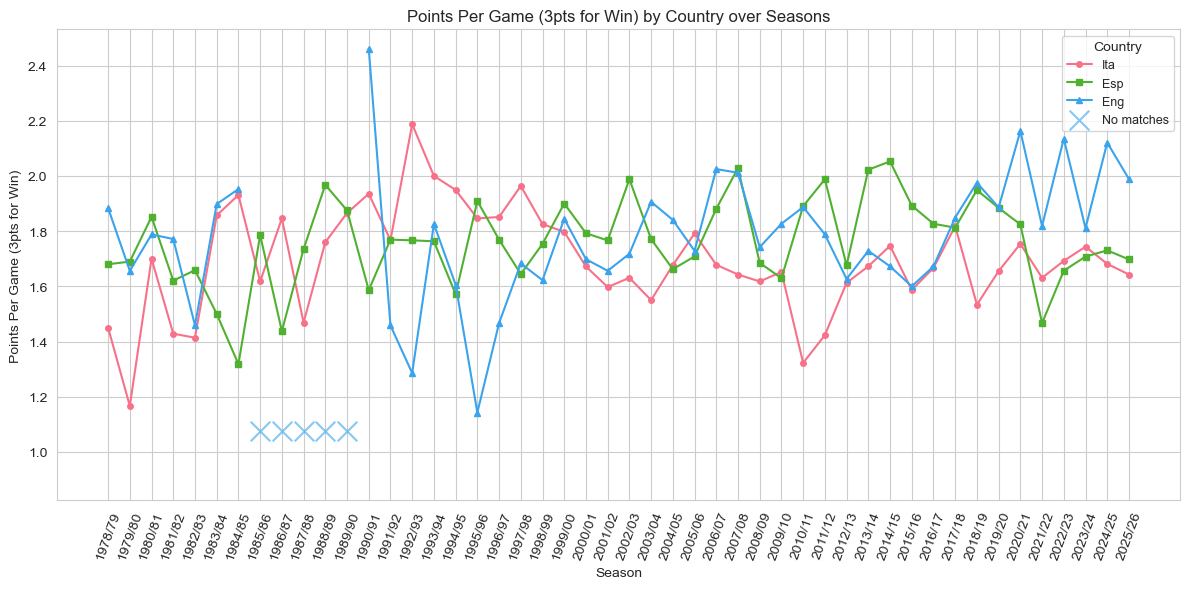

In [34]:
plot_country_metrics(country_stats_complete, countries=['Ita', 'Esp', 'Eng'], metric='ppg_3')

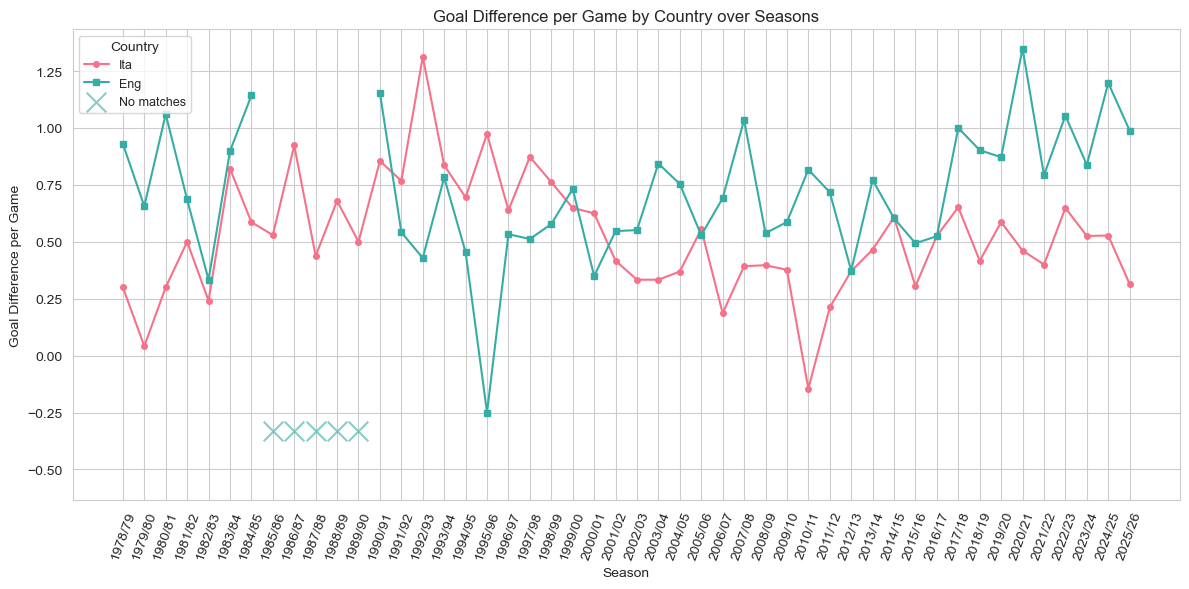

In [35]:
plot_country_metrics(country_stats_complete, countries=['Ita','Eng'], metric='gdpg')

In [36]:
country_stats_complete.head()

,country,season,num_teams,wins,draws,losses,goals_for,goals_against,total_matches,win_rate,draw_rate,loss_rate,ppg_3,ppg_2,goal_diff,gf_pg,ga_pg,gdpg
0,Alb,1978/79,1,1,0,1,3.0,4.0,2,0.50,0.00,0.50,1.50,1.00,-1.0,1.50,2.00,-0.50
1,Alb,1979/80,1,1,0,1,2.0,4.0,2,0.50,0.00,0.50,1.50,1.00,-2.0,1.00,2.00,-1.00
2,Alb,1980/81,2,0,1,3,0.0,4.0,4,0.00,0.25,0.75,0.25,0.25,-4.0,0.00,1.00,-1.00
3,Alb,1981/82,2,2,0,2,3.0,7.0,4,0.50,0.00,0.50,1.50,1.00,-4.0,0.75,1.75,-1.00
4,Alb,1982/83,2,1,1,2,2.0,3.0,4,0.25,0.25,0.50,1.00,0.75,-1.0,0.50,0.75,-0.25


In [37]:
get_countries_seasons_details(raw_data, ['1995/96'], ['Eng'])   

,season,competition,round,team_a,country_a,team_b,country_b,score_leg1,score_leg2,score_aggregate,extra_time,penalties
2246,1995/96,CL,Group Stage,Blackburn Rovers,Eng,Spartak Moscow,Rus,0-1,0-3,0-4,no,no
2248,1995/96,CL,Group Stage,Rosenborg BK,Nor,Blackburn Rovers,Eng,2-1,1-4,3-5,no,no
2249,1995/96,CL,Group Stage,Legia Warsaw,Pol,Blackburn Rovers,Eng,1-0,0-0,1-0,no,no
2288,1995/96,CW,Round 1,KR Reykjavik,Isl,Everton,Eng,2-3,1-3,3-6,no,no
2303,1995/96,CW,Round 2,Everton,Eng,Feyenoord,Ned,0-0,0-1,0-1,no,no
2352,1995/96,EL,Round 1,Rotor Volgograd,Rus,Manchester United,Eng,0-0,2-2,2-2,no,no
2370,1995/96,EL,Round 1,Malmö FF,Swe,Nottingham Forest,Eng,2-1,0-1,2-2,no,no
2372,1995/96,EL,Round 1,AS Monaco,Fra,Leeds United,Eng,0-3,1-0,1-3,no,no
2378,1995/96,EL,Round 1,Alania Vladikavkaz,Rus,Liverpool,Eng,1-2,0-0,1-2,no,no
2381,1995/96,EL,Round 2,Brøndby IF,Den,Liverpool,Eng,0-0,1-0,1-0,no,no


In [38]:
get_countries_seasons_details(raw_data, ['2020/21'], ['Eng'])   

,season,competition,round,team_a,country_a,team_b,country_b,score_leg1,score_leg2,score_aggregate,extra_time,penalties
9878,2020/21,CL,Group Stage,Manchester City,Eng,FC Porto,Por,3-1,0-0,3-1,no,no
9880,2020/21,CL,Group Stage,Olympique Marseille,Fra,Manchester City,Eng,0-3,0-3,0-6,no,no
9883,2020/21,CL,Group Stage,Manchester City,Eng,Olympiakos Piraeus,Gre,3-0,1-0,4-0,no,no
9885,2020/21,CL,Group Stage,Ajax,Ned,Liverpool,Eng,0-1,0-1,0-2,no,no
9886,2020/21,CL,Group Stage,Liverpool,Eng,FC Midtjylland,Den,2-0,1-1,3-1,no,no
9888,2020/21,CL,Group Stage,Atalanta,Ita,Liverpool,Eng,0-5,2-0,2-5,no,no
9890,2020/21,CL,Group Stage,Chelsea,Eng,Sevilla,Esp,0-0,4-0,4-0,no,no
9892,2020/21,CL,Group Stage,FK Krasnodar,Rus,Chelsea,Eng,0-4,1-1,1-5,no,no
9895,2020/21,CL,Group Stage,Chelsea,Eng,Stade Rennais,Fra,3-0,2-1,5-1,no,no
9909,2020/21,CL,Group Stage,Paris Saint-Germain,Fra,Manchester United,Eng,1-2,3-1,4-3,no,no


## Analysis-Ready dataset 

In [39]:
country_stats_complete.head()

,country,season,num_teams,wins,draws,losses,goals_for,goals_against,total_matches,win_rate,draw_rate,loss_rate,ppg_3,ppg_2,goal_diff,gf_pg,ga_pg,gdpg
0,Alb,1978/79,1,1,0,1,3.0,4.0,2,0.50,0.00,0.50,1.50,1.00,-1.0,1.50,2.00,-0.50
1,Alb,1979/80,1,1,0,1,2.0,4.0,2,0.50,0.00,0.50,1.50,1.00,-2.0,1.00,2.00,-1.00
2,Alb,1980/81,2,0,1,3,0.0,4.0,4,0.00,0.25,0.75,0.25,0.25,-4.0,0.00,1.00,-1.00
3,Alb,1981/82,2,2,0,2,3.0,7.0,4,0.50,0.00,0.50,1.50,1.00,-4.0,0.75,1.75,-1.00
4,Alb,1982/83,2,1,1,2,2.0,3.0,4,0.25,0.25,0.50,1.00,0.75,-1.0,0.50,0.75,-0.25


This is a list of the analysis-ready datasets we produced from the wrangling analysis



In [40]:
country_stats.head()

,country,season,num_teams,wins,draws,losses,goals_for,goals_against
0,Alb,1978/79,1,1,0,1,3.0,4.0
1,Alb,1979/80,1,1,0,1,2.0,4.0
2,Alb,1980/81,2,0,1,3,0.0,4.0
3,Alb,1981/82,2,2,0,2,3.0,7.0
4,Alb,1982/83,2,1,1,2,2.0,3.0


In [41]:
country_stats_complete.columns

Index(['country', 'season', 'num_teams', 'wins', 'draws', 'losses',
       'goals_for', 'goals_against', 'total_matches', 'win_rate', 'draw_rate',
       'loss_rate', 'ppg_3', 'ppg_2', 'goal_diff', 'gf_pg', 'ga_pg', 'gdpg'],
      dtype='str')

In [42]:
country_stats_complete.dtypes

country              str
season               str
num_teams          int64
wins               int64
draws              int64
losses             int64
goals_for        float64
goals_against    float64
total_matches      int64
win_rate         float64
draw_rate        float64
loss_rate        float64
ppg_3            float64
ppg_2            float64
goal_diff        float64
gf_pg            float64
ga_pg            float64
gdpg             float64
dtype: object

In [43]:
country_season_competition_highest.columns

Index(['season', 'country', 'competition', 'highest_round'], dtype='str')

In [44]:
country_season_competition_highest['competition'].unique()

<StringArray>
['CL', 'CO', 'CW', 'EL']
Length: 4, dtype: str

In [45]:
raw_data.columns

Index(['season', 'competition', 'round', 'team_a', 'country_a', 'team_b',
       'country_b', 'score_leg1', 'score_leg2', 'score_aggregate',
       'extra_time', 'penalties'],
      dtype='str')

In [ ]:
# save processed data for later use in analysis and visualization
raw_data.to_pickle('../data/processed/raw_data.pkl')
country_stats_complete.to_pickle('../data/processed/country_stats_complete.pkl')
country_season_highest.to_pickle('../data/processed/country_season_highest.pkl')
country_season_competition_highest.to_pickle('../data/processed/country_season_competition_highest.pkl')    
